# TCR Repertoire Aging — Functional Diversity Analysis

Extends the basic aging analysis (`aging_analysis.ipynb`) with metaclonotype-based
functional diversity metrics computed on 100 k-read-downsampled TRB repertoires from
the Hugging Face AIRR benchmark (Britanova et al. 2016 aging cohort).

**Metaclonotype clustering:** 1-mismatch Hamming edit-distance graph, Louvain
communities, minimum cluster size 2.

**Metrics compared side-by-side:**

| Metric | Clonotypic | Functional |
|---|---|---|
| Diversity (Shannon q=1) | Shannon over clonotypes | Shannon over metaclonotype clusters |
| Rarefaction | Clonotype-level iNEXT | Metaclonotype-level rarefaction |
| Pairwise F overlap | Clonotypic F similarity (exact) | Functional F (metaclonotype identity sharing) |
| Vs-pool F overlap | Clonotypic donor-vs-pool | Functional donor-vs-pool |

Reference: Britanova OV et al. *J Immunol.* 2016.

In [1]:
# Cell 1: Environment versions
import platform, importlib, sys
print('Python:', platform.python_version())
for pkg in ('numpy', 'polars', 'scipy', 'matplotlib', 'igraph', 'mir'):
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg}: {getattr(m, "__version__", "?")}')
    except ImportError:
        print(f'  {pkg}: NOT INSTALLED')

Python: 3.12.12
  numpy: 1.26.4
  polars: 1.40.1
  scipy: 1.17.1


  matplotlib: 3.10.9
  igraph: 1.0.0
  mir: ?


In [2]:
# Cell 2: Imports
import os
import time
import warnings
from pathlib import Path

import numpy as np
import polars as pl
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mir.common.parser import VDJtoolsParser
from mir.common.repertoire import LocusRepertoire
from mir.common.sampling import downsample
from mir.common.diversity import (
    summarize_clonotypes,
    hill_curve_clonotypes,
    rarefaction_curve_clonotypes,
)
from mir.common.metaclonotype import (
    functional_diversity,
    functional_hill_curve,
    functional_rarefaction_curve,
    functional_overlap_1,
)
from mir.comparative.overlap import pairwise_overlap_matrix, many_vs_pool_overlap
from mir.comparative import clear_pairwise_target_cache
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.metaclonotype_clustering import metaclonotypes_from_graph_communities
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mir.common.sampling')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'STIXGeneral',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
})

DOWNSAMPLE_TARGET = 100_000
METACLONOTYPE_METHOD = 'louvain'
METACLONOTYPE_THRESHOLD = 1
METACLONOTYPE_MIN_SIZE = 2
N_JOBS = 4

clear_pairwise_target_cache()
EXECUTION_TIMES: dict[str, float] = {}
print('Setup complete.')

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [3]:
# Cell 3: Resolve data root and refresh AIRR benchmark
repo_root = find_repo_root(Path.cwd())

t0 = time.perf_counter()
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=['vdjtools/**'])
EXECUTION_TIMES['asset_refresh_s'] = time.perf_counter() - t0

VDJTOOLS_DIR = benchmark_root / 'vdjtools'
META_PATH = VDJTOOLS_DIR / 'metadata_aging.txt'
if not META_PATH.exists():
    raise FileNotFoundError(f'Missing {META_PATH}')

repertoire_lookup = {p.name: p for p in sorted(VDJTOOLS_DIR.glob('*.txt.gz'))}
print(f'Benchmark root      : {benchmark_root}')
print(f'Indexed repertoires : {len(repertoire_lookup):,}')

Benchmark root      : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark
Indexed repertoires : 316


In [4]:
# Cell 4: Load aging metadata
meta = pl.read_csv(META_PATH, separator='\t')

rename_map = {c: c.lstrip('#') for c in meta.columns if c.startswith('#')}
if rename_map:
    meta = meta.rename(rename_map)

meta = meta.with_columns([
    pl.col('sample_id').cast(pl.Utf8),
    pl.col('file_name').cast(pl.Utf8),
    pl.col('age').cast(pl.Int64),
])

print(f'Metadata rows : {meta.height}  '
      f'Age range: {meta["age"].min()}\u2013{meta["age"].max()} y  '
      f'Cord-blood: {meta.filter(pl.col("age")==0).height}')
meta.head(6).to_pandas()

Metadata rows : 79  Age range: 0–103 y  Cord-blood: 8


,file_name,sample_id,sex,age,label
0,A3-i101.txt,A3-i101,F,36,p1-F36
1,A3-i102.txt,A3-i102,F,43,p2-F43
2,A3-i106.txt,A3-i106,F,43,p3-F43
3,A3-i107.txt,A3-i107,F,39,p4-F39
4,A3-i110.txt,A3-i110,F,34,p5-F34
5,A3-i145.txt,A3-i145,F,86,p6-F86


In [5]:
# Cell 5: Load and downsample repertoires to 100k reads
parser = VDJtoolsParser(sep='\t')

def _resolve(file_name: str) -> Path | None:
    for cand in [file_name, f'{file_name}.gz', file_name.replace('.txt', '.txt.gz'), file_name.replace('.gz', '')]:
        p = repertoire_lookup.get(cand)
        if p is not None and p.exists():
            return p
    return None

reps, loaded_rows = [], []
t0 = time.perf_counter()
for row in meta.iter_rows(named=True):
    p = _resolve(str(row['file_name']))
    if p is None:
        continue
    clones = parser.parse(str(p))
    rep = LocusRepertoire(clonotypes=clones, locus='TRB')
    rep = downsample(rep, DOWNSAMPLE_TARGET, random_seed=42)
    reps.append(rep)
    loaded_rows.append({'sample_id': row['sample_id'], 'age': int(row['age']), 'sex': row.get('sex')})
EXECUTION_TIMES['load_s'] = time.perf_counter() - t0

meta_valid = pl.DataFrame(loaded_rows)
sample_ids = meta_valid['sample_id'].to_list()
ages = meta_valid['age'].to_list()
ages_arr = np.array(ages, dtype=float)

clonotype_counts = np.array([r.clonotype_count for r in reps], dtype=int)
print(f'Loaded {len(reps)} repertoires in {EXECUTION_TIMES["load_s"]:.1f}s')
print(f'Clonotype count: min={clonotype_counts.min():,} '
      f'median={int(np.median(clonotype_counts)):,} '
      f'max={clonotype_counts.max():,}')

Loaded 79 repertoires in 108.4s
Clonotype count: min=12,439 median=51,303 max=93,154


## 1 · Clonotypic diversity

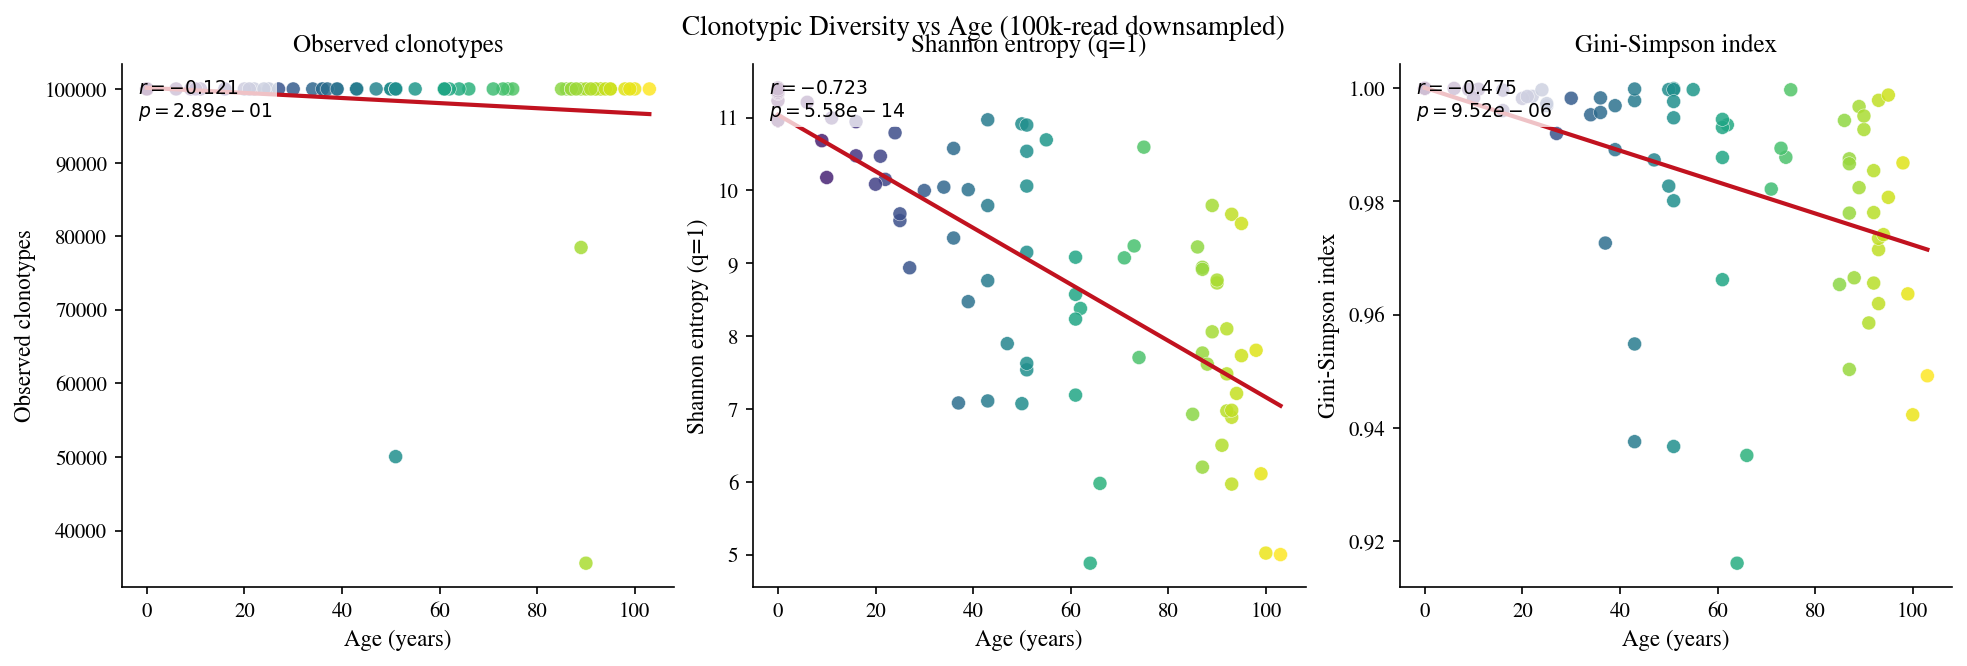

In [6]:
# Cell 6: Clonotypic diversity per sample
div_rows = []
for sid, age, rep in zip(sample_ids, ages, reps):
    d = summarize_clonotypes(rep.clonotypes)
    div_rows.append({
        'sample_id': sid, 'age': age,
        'n_clonotypes': d.abundance,
        'shannon': d.shannon,
        'gini_simpson': d.gini_simpson,
        'chao1': d.chao1,
    })
clono_div_df = pl.DataFrame(div_rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for ax, (col, label) in zip(axes, [
    ('n_clonotypes', 'Observed clonotypes'),
    ('shannon', 'Shannon entropy (q=1)'),
    ('gini_simpson', 'Gini-Simpson index'),
]):
    x = ages_arr
    y = clono_div_df[col].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=45, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.text(0.03, 0.97, f'$r={r:.3f}$\n$p={p:.2e}$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Clonotypic Diversity vs Age (100k-read downsampled)', fontsize=13, y=1.02)
plt.show()

## 2 · Clonotypic rarefaction

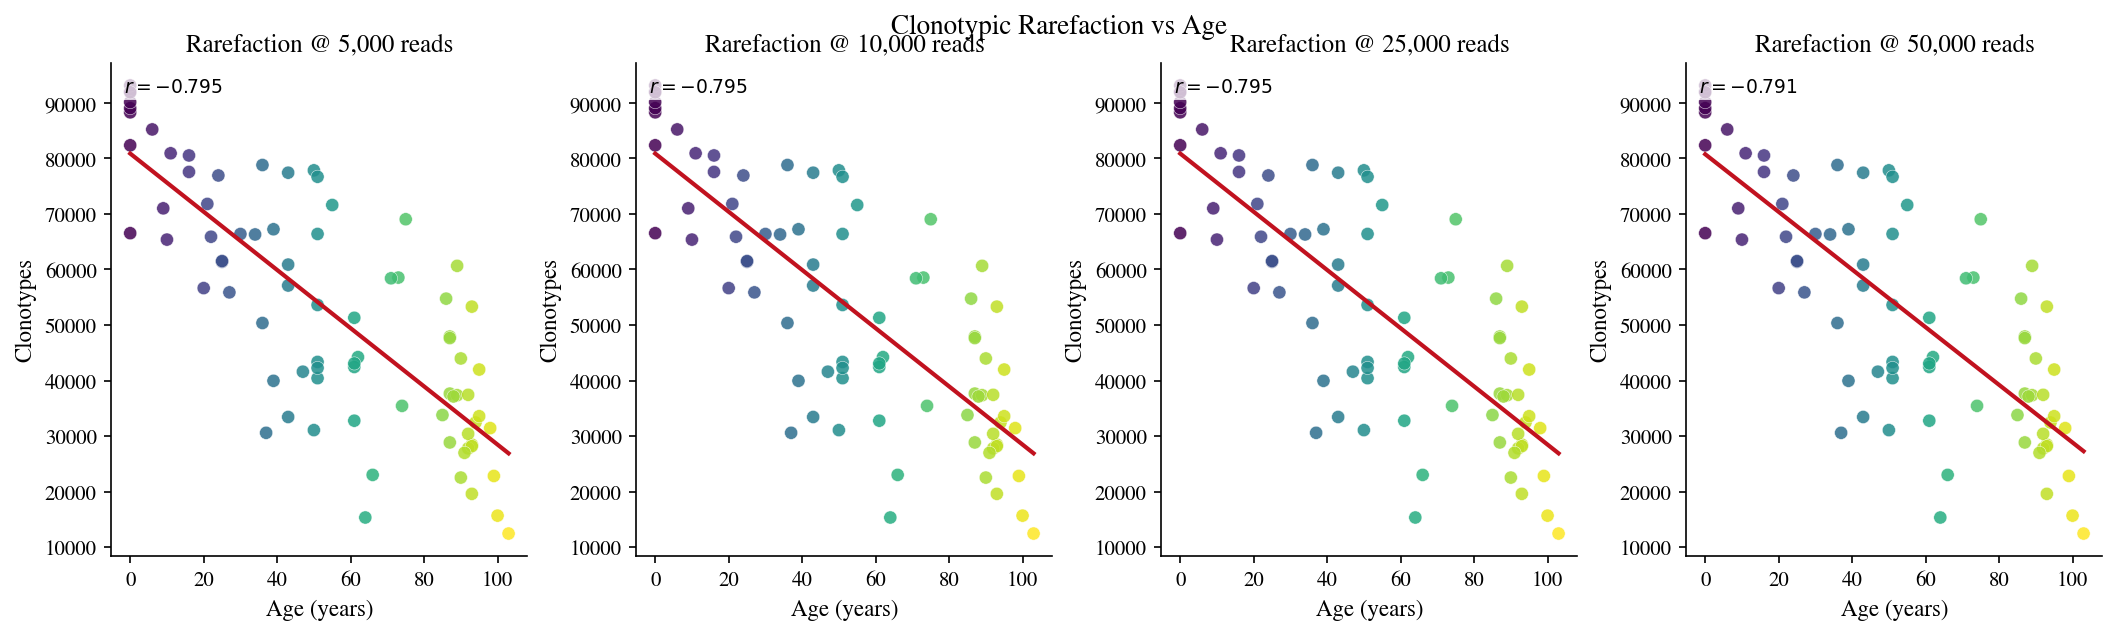

In [7]:
# Cell 7: Clonotypic rarefaction at multiple depths
RARE_DEPTHS = [5_000, 10_000, 25_000, 50_000]

rare_rows = []
for sid, age, rep in zip(sample_ids, ages, reps):
    total = int(sum(c.duplicate_count for c in rep.clonotypes))
    for m in RARE_DEPTHS:
        if m > total:
            continue
        curve = rarefaction_curve_clonotypes(rep.clonotypes, m_steps=[m], include_exact=True)
        row = curve.filter(pl.col('m') == m)
        if row.height:
            rare_rows.append({'sample_id': sid, 'age': age, 'm': m,
                               'D': float(row['s_obs'][0])})

rare_df = pl.DataFrame(rare_rows)

fig, axes = plt.subplots(1, len(RARE_DEPTHS), figsize=(14, 4), constrained_layout=True, sharey=False)
for ax, m in zip(axes, RARE_DEPTHS):
    sub = rare_df.filter(pl.col('m') == m)
    if sub.height == 0:
        ax.set_title(f'{m:,} reads\n(no data)')
        continue
    x = sub['age'].to_numpy().astype(float)
    y = sub['D'].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=40, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Clonotypes')
    ax.set_title(f'Rarefaction @ {m:,} reads')
    ax.text(0.03, 0.97, f'$r={r:.3f}$', transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Clonotypic Rarefaction vs Age', fontsize=13, y=1.02)
plt.show()

## 3 · Clonotypic pairwise F overlap

In [8]:
# Cell 8: Clonotypic pairwise F similarity (exact, aavj)
t0 = time.perf_counter()
clono_pairs_pd = pairwise_overlap_matrix(
    reps, sample_ids=sample_ids,
    metric='exact', threshold=0,
    overlap_space='aavj', n_jobs=N_JOBS,
)
EXECUTION_TIMES['clono_pairwise_s'] = time.perf_counter() - t0
clono_pairs = pl.from_pandas(clono_pairs_pd)
print(f'Clonotypic pairwise: {clono_pairs.height:,} pairs in '
      f'{EXECUTION_TIMES["clono_pairwise_s"]:.1f}s')

Clonotypic pairwise: 3,081 pairs in 25.8s


In [9]:
# Cell 9: Clonotypic donor-vs-pool F overlap
pool_rep = LocusRepertoire(
    clonotypes=[c for rep in reps for c in rep.clonotypes],
    locus='TRB',
)
print(f'Pool: {pool_rep.clonotype_count:,} clonotypes')

t0 = time.perf_counter()
clono_pool_df = many_vs_pool_overlap(
    reps, pool_rep, sample_ids=sample_ids, ages=ages,
    metric='exact', threshold=0, overlap_space='aavj', n_jobs=N_JOBS,
)
EXECUTION_TIMES['clono_pool_s'] = time.perf_counter() - t0
print(f'Done in {EXECUTION_TIMES["clono_pool_s"]:.1f}s')

Pool: 4,145,989 clonotypes


Done in 28.2s


## 4 · Metaclonotype clustering (1mm Hamming + Louvain)

Each sample is clustered independently.  Clonotypes with identical CDR3 amino-acid sequences
that differ by at most 1 Hamming substitution are placed in the same cluster (without
V/J gene restriction).  Singletons (clusters of size 1) are discarded.  The Louvain
algorithm further merges multi-hop connected dense neighbourhoods.

In [10]:
# Cell 10: Per-sample metaclonotype clustering
# ~5–15 s per sample → ~7–20 min total for 79 samples

from mir.common.metaclonotype import MetaClonotypeClustering

meta_clusterings: list[MetaClonotypeClustering] = []
cluster_count_rows = []

t0 = time.perf_counter()
for i, (sid, age, rep) in enumerate(zip(sample_ids, ages, reps)):
    t_rep = time.perf_counter()
    graph = build_edit_distance_graph(
        rep.clonotypes,
        metric='hamming',
        threshold=METACLONOTYPE_THRESHOLD,
        n_jobs=N_JOBS,
    )
    mc = metaclonotypes_from_graph_communities(
        graph,
        method=METACLONOTYPE_METHOD,
        min_cluster_size=METACLONOTYPE_MIN_SIZE,
    )
    meta_clusterings.append(mc)
    cluster_count_rows.append({
        'sample_id': sid, 'age': age,
        'n_clonotypes': rep.clonotype_count,
        'n_clusters': mc.n_clusters,
        'cluster_s': round(time.perf_counter() - t_rep, 2),
    })
    if (i + 1) % 10 == 0:
        elapsed = time.perf_counter() - t0
        print(f'  [{i+1}/{len(reps)}] {elapsed:.0f}s elapsed — '
              f'last cluster: {mc.n_clusters} groups in {cluster_count_rows[-1]["cluster_s"]:.1f}s')

EXECUTION_TIMES['meta_cluster_s'] = time.perf_counter() - t0
cluster_df = pl.DataFrame(cluster_count_rows)
print(f'\nClustered {len(reps)} samples in {EXECUTION_TIMES["meta_cluster_s"]:.1f}s')
print(f'Clusters per sample: '
      f'min={cluster_df["n_clusters"].min()} '
      f'median={int(cluster_df["n_clusters"].median())} '
      f'max={cluster_df["n_clusters"].max()}')

Skipping 1814 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1814 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1814 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1814 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1043 sequences with non-canonical amino acids (*, _, or non-standard chars)


...

Skipping 1359 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1218 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1218 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1218 sequences with non-canonical amino acids (*, _, or non-standard chars)



Clustered 79 samples in 1257.1s
Clusters per sample: min=633 median=2189 max=3271


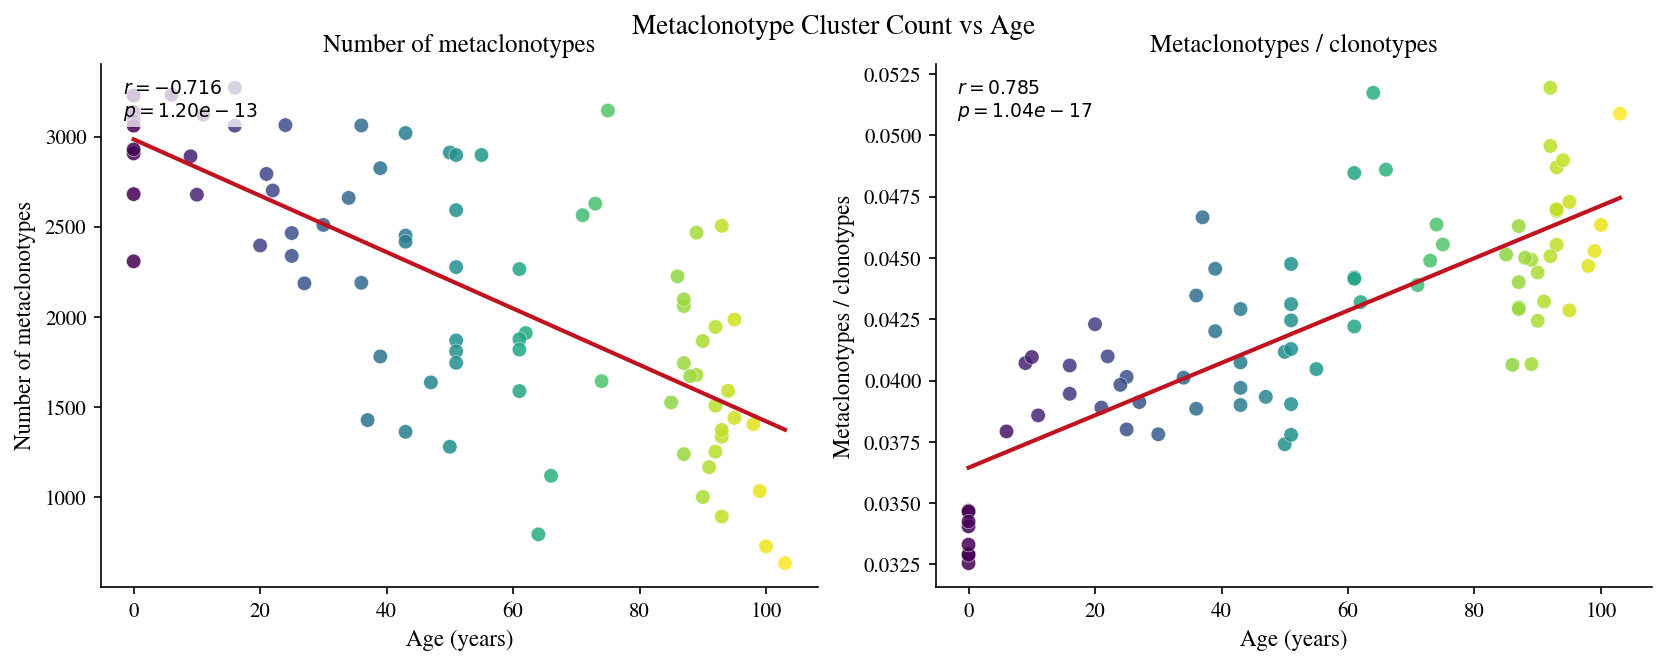

In [11]:
# Cell 11: Cluster count and compression ratio vs age
cluster_df = cluster_df.with_columns(
    (pl.col('n_clusters') / pl.col('n_clonotypes')).alias('compression')
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, (col, label) in zip(axes, [
    ('n_clusters', 'Number of metaclonotypes'),
    ('compression', 'Metaclonotypes / clonotypes'),
]):
    x = cluster_df['age'].to_numpy().astype(float)
    y = cluster_df[col].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=48, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.text(0.03, 0.97, f'$r={r:.3f}$\n$p={p:.2e}$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Metaclonotype Cluster Count vs Age', fontsize=13, y=1.02)
plt.show()

## 5 · Functional diversity

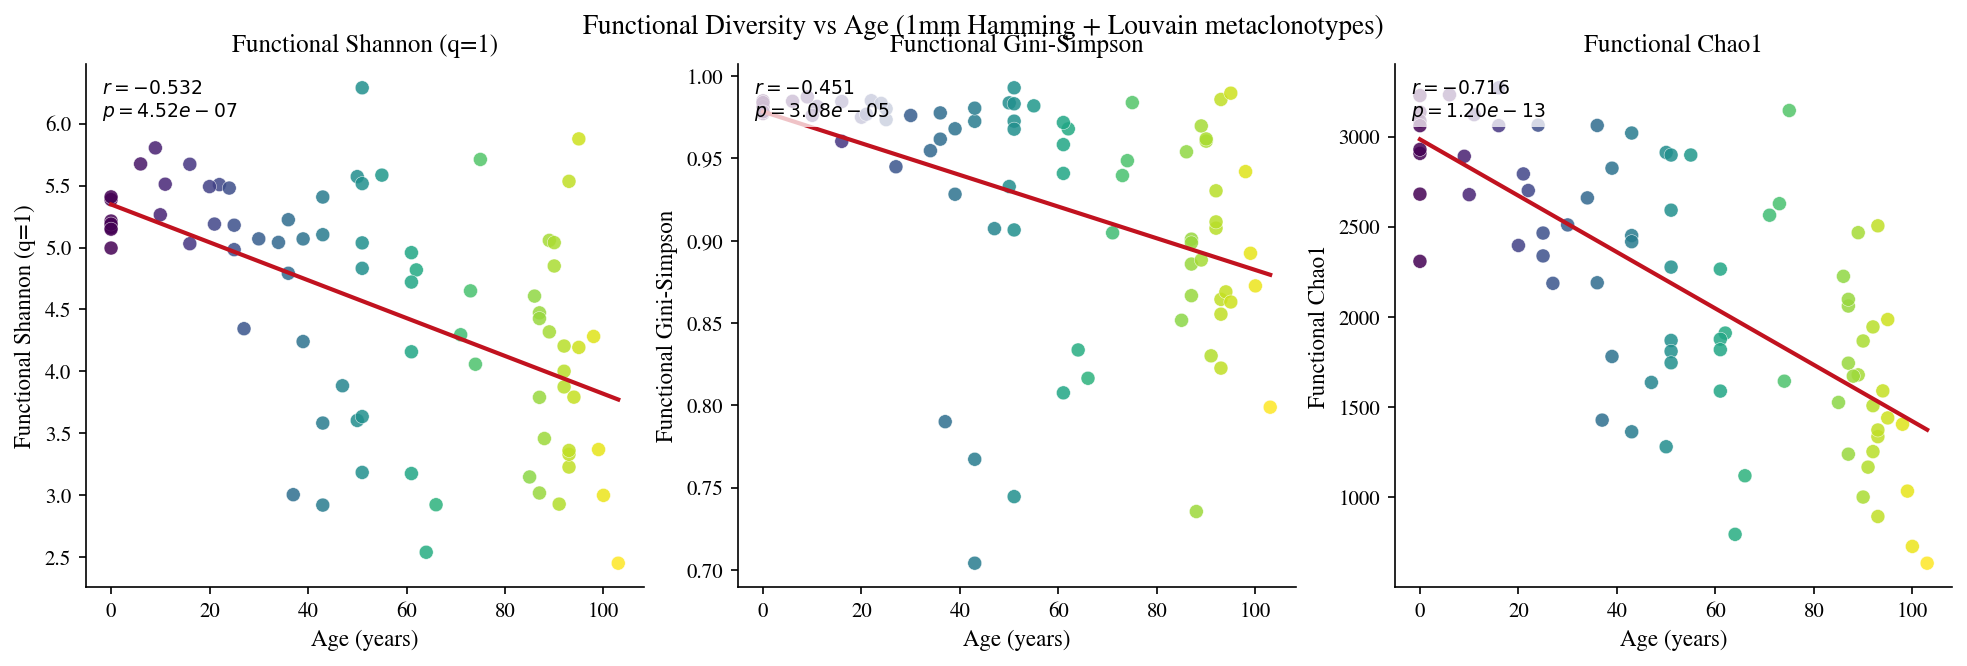

In [12]:
# Cell 12: Functional diversity per sample (Shannon at metaclonotype level)
func_div_rows = []
for sid, age, rep, mc in zip(sample_ids, ages, reps, meta_clusterings):
    if mc.n_clusters == 0:
        continue
    d = functional_diversity(rep, mc)
    func_div_rows.append({
        'sample_id': sid, 'age': age,
        'func_shannon': d.shannon,
        'func_gini_simpson': d.gini_simpson,
        'func_chao1': d.chao1,
    })
func_div_df = pl.DataFrame(func_div_rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for ax, (col, label) in zip(axes, [
    ('func_shannon', 'Functional Shannon (q=1)'),
    ('func_gini_simpson', 'Functional Gini-Simpson'),
    ('func_chao1', 'Functional Chao1'),
]):
    x = func_div_df['age'].to_numpy().astype(float)
    y = func_div_df[col].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=45, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.text(0.03, 0.97, f'$r={r:.3f}$\n$p={p:.2e}$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Functional Diversity vs Age (1mm Hamming + Louvain metaclonotypes)', fontsize=13, y=1.02)
plt.show()

## 6 · Functional rarefaction

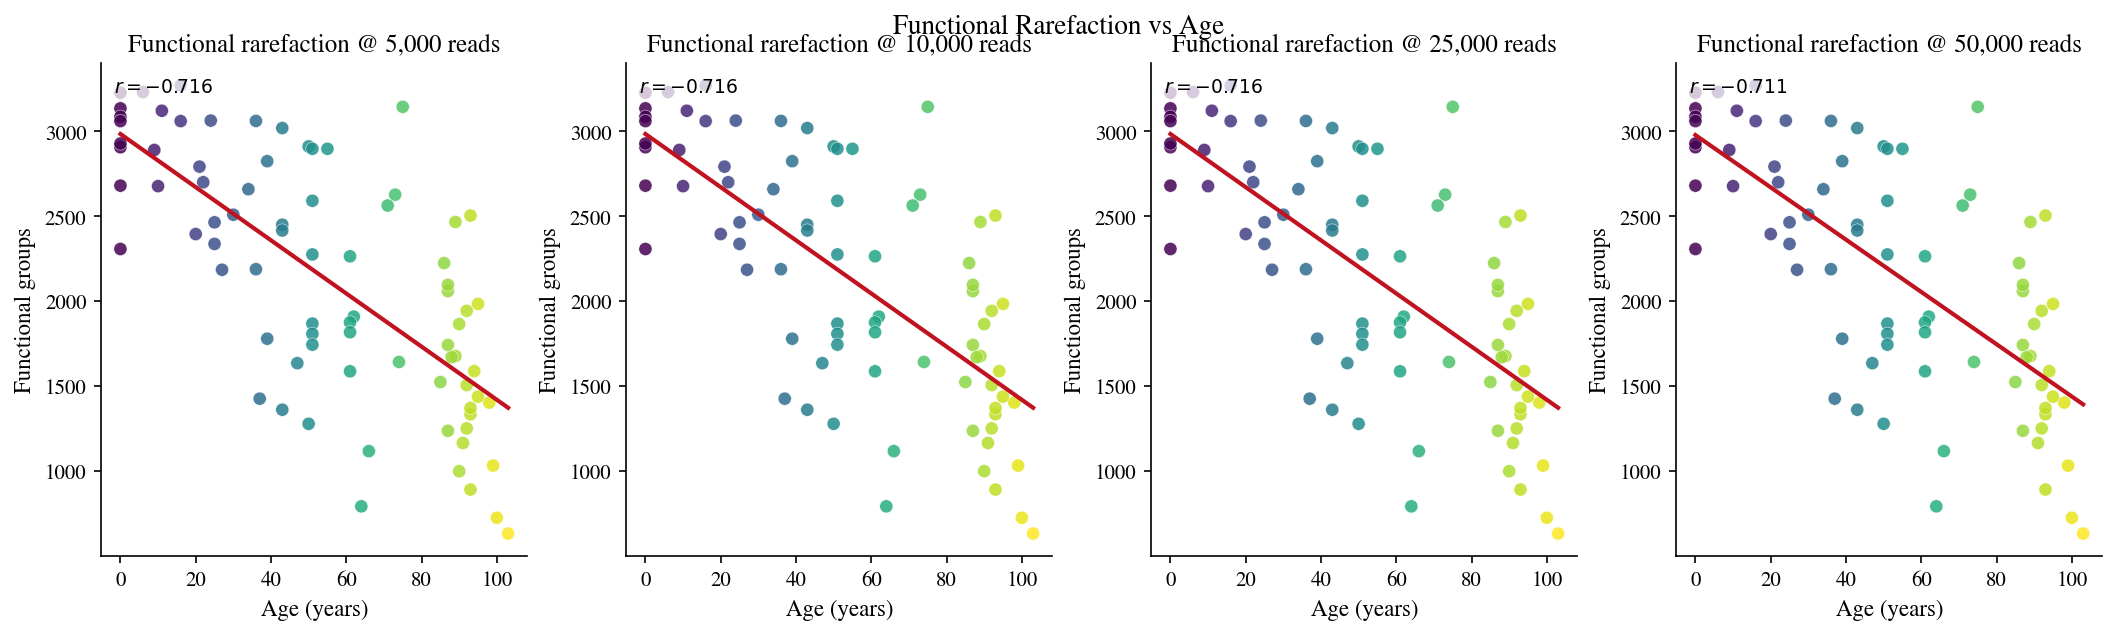

In [13]:
# Cell 13: Functional rarefaction at multiple depths
FUNC_RARE_DEPTHS = [5_000, 10_000, 25_000, 50_000]

func_rare_rows = []
for sid, age, rep, mc in zip(sample_ids, ages, reps, meta_clusterings):
    if mc.n_clusters == 0:
        continue
    total = int(sum(c.duplicate_count for c in rep.clonotypes))
    valid_depths = [m for m in FUNC_RARE_DEPTHS if m <= total]
    if not valid_depths:
        continue
    try:
        curve = functional_rarefaction_curve(rep, mc, m_steps=valid_depths, include_exact=False)
        for m in valid_depths:
            row = curve.filter(pl.col('m') == m)
            if row.height:
                func_rare_rows.append({
                    'sample_id': sid, 'age': age, 'm': m,
                    'D': float(row['s_obs'][0]),
                })
    except Exception:
        pass

func_rare_df = pl.DataFrame(func_rare_rows)

fig, axes = plt.subplots(1, len(FUNC_RARE_DEPTHS), figsize=(14, 4), constrained_layout=True)
for ax, m in zip(axes, FUNC_RARE_DEPTHS):
    sub = func_rare_df.filter(pl.col('m') == m)
    if sub.height < 2:
        ax.set_title(f'{m:,} reads\n(insufficient data)')
        continue
    x = sub['age'].to_numpy().astype(float)
    y = sub['D'].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=40, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Functional groups')
    ax.set_title(f'Functional rarefaction @ {m:,} reads')
    ax.text(0.03, 0.97, f'$r={r:.3f}$', transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Functional Rarefaction vs Age', fontsize=13, y=1.02)
plt.show()

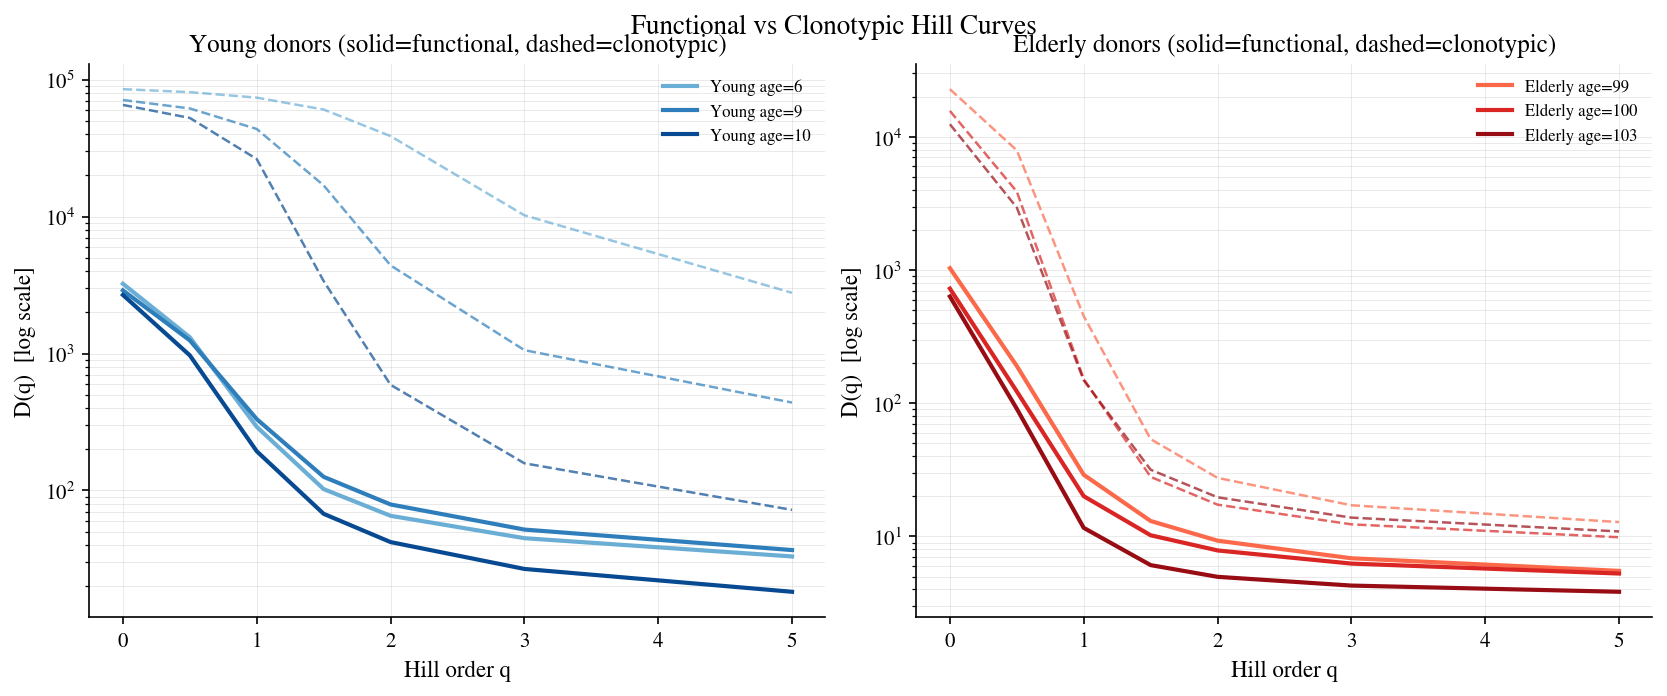

In [14]:
# Cell 14: Functional Hill curves for young vs elderly donors
# Pick 3 youngest and 3 oldest samples (exclude cord-blood age=0)
age_sorted = sorted(
    [(age, i) for i, age in enumerate(ages) if age > 0],
    key=lambda t: t[0]
)
young_idx = [i for _, i in age_sorted[:3]]
old_idx = [i for _, i in age_sorted[-3:]]

q_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
colors_young = plt.cm.Blues(np.linspace(0.5, 0.9, 3))
colors_old = plt.cm.Reds(np.linspace(0.5, 0.9, 3))

for ax, (group_idx, colors, group_label) in zip(
    axes,
    [(young_idx, colors_young, 'Young'), (old_idx, colors_old, 'Elderly')]
):
    for j, (idx, col) in enumerate(zip(group_idx, colors)):
        rep = reps[idx]
        mc = meta_clusterings[idx]
        age = ages[idx]
        if mc.n_clusters < 2:
            continue
        # Clonotypic Hill (dashed) — column is 'hill'
        hill_c = hill_curve_clonotypes(rep.clonotypes, q_values=q_values)
        ax.plot(hill_c['q'], hill_c['hill'], '--', color=col, lw=1.2, alpha=0.7)
        # Functional Hill (solid) — column is 'hill'
        hill_f = functional_hill_curve(rep, mc, q_values=q_values)
        ax.plot(hill_f['q'], hill_f['hill'], '-', color=col, lw=2,
                label=f'{group_label} age={age}')
    ax.set_yscale('log')
    ax.set_xlabel('Hill order q')
    ax.set_ylabel('D(q)  [log scale]')
    ax.set_title(f'{group_label} donors (solid=functional, dashed=clonotypic)')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.3, which='both')
fig.suptitle('Functional vs Clonotypic Hill Curves', fontsize=13, y=1.02)
plt.show()


## 7 · Functional pairwise F overlap

The functional F overlap between two samples A and B is defined as:

$$F_{\text{func}}(A,B) = \frac{2 \cdot |\text{shared}_A| \cdot |\text{shared}_B|}{|\text{clusters}_A| \cdot |\text{shared}_B| + |\text{clusters}_B| \cdot |\text{shared}_A|}$$

where $|\text{shared}_A|$ is the number of metaclonotype groups in A that share at least one clonotype identity with any group in B (and vice versa).  This is the F1-score (harmonic mean) of the two asymmetric sharing fractions.

In [15]:
# Cell 15: Functional pairwise F overlap
# O(N^2) calls to functional_overlap_1 — fast because identity sets are cached per sample.

n = len(reps)
func_pair_rows = []

t0 = time.perf_counter()
for i in range(n):
    rep_a, mc_a, sid_a, age_a = reps[i], meta_clusterings[i], sample_ids[i], ages[i]
    if mc_a.n_clusters == 0:
        continue
    for j in range(i + 1, n):
        rep_b, mc_b, sid_b, age_b = reps[j], meta_clusterings[j], sample_ids[j], ages[j]
        if mc_b.n_clusters == 0:
            continue
        r = functional_overlap_1(rep_a, mc_a, rep_b, mc_b)
        sa = float(r['a_shared_clusters'][0])
        sb = float(r['b_shared_clusters'][0])
        ca = float(r['a_clusters'][0])
        cb = float(r['b_clusters'][0])
        denom = ca * sb + cb * sa
        f_func = 2 * sa * sb / denom if denom > 0 else 0.0
        func_pair_rows.append({
            'sample_id_1': sid_a, 'sample_id_2': sid_b,
            'age1': age_a, 'age2': age_b,
            'age_diff': abs(age_a - age_b),
            'f_func': f_func,
            'frac_a': sa / ca if ca > 0 else 0.0,
            'frac_b': sb / cb if cb > 0 else 0.0,
        })

EXECUTION_TIMES['func_pairwise_s'] = time.perf_counter() - t0
func_pair_df = pl.DataFrame(func_pair_rows)
print(f'Functional pairwise: {func_pair_df.height:,} pairs in '
      f'{EXECUTION_TIMES["func_pairwise_s"]:.1f}s')

Functional pairwise: 3,081 pairs in 167.9s


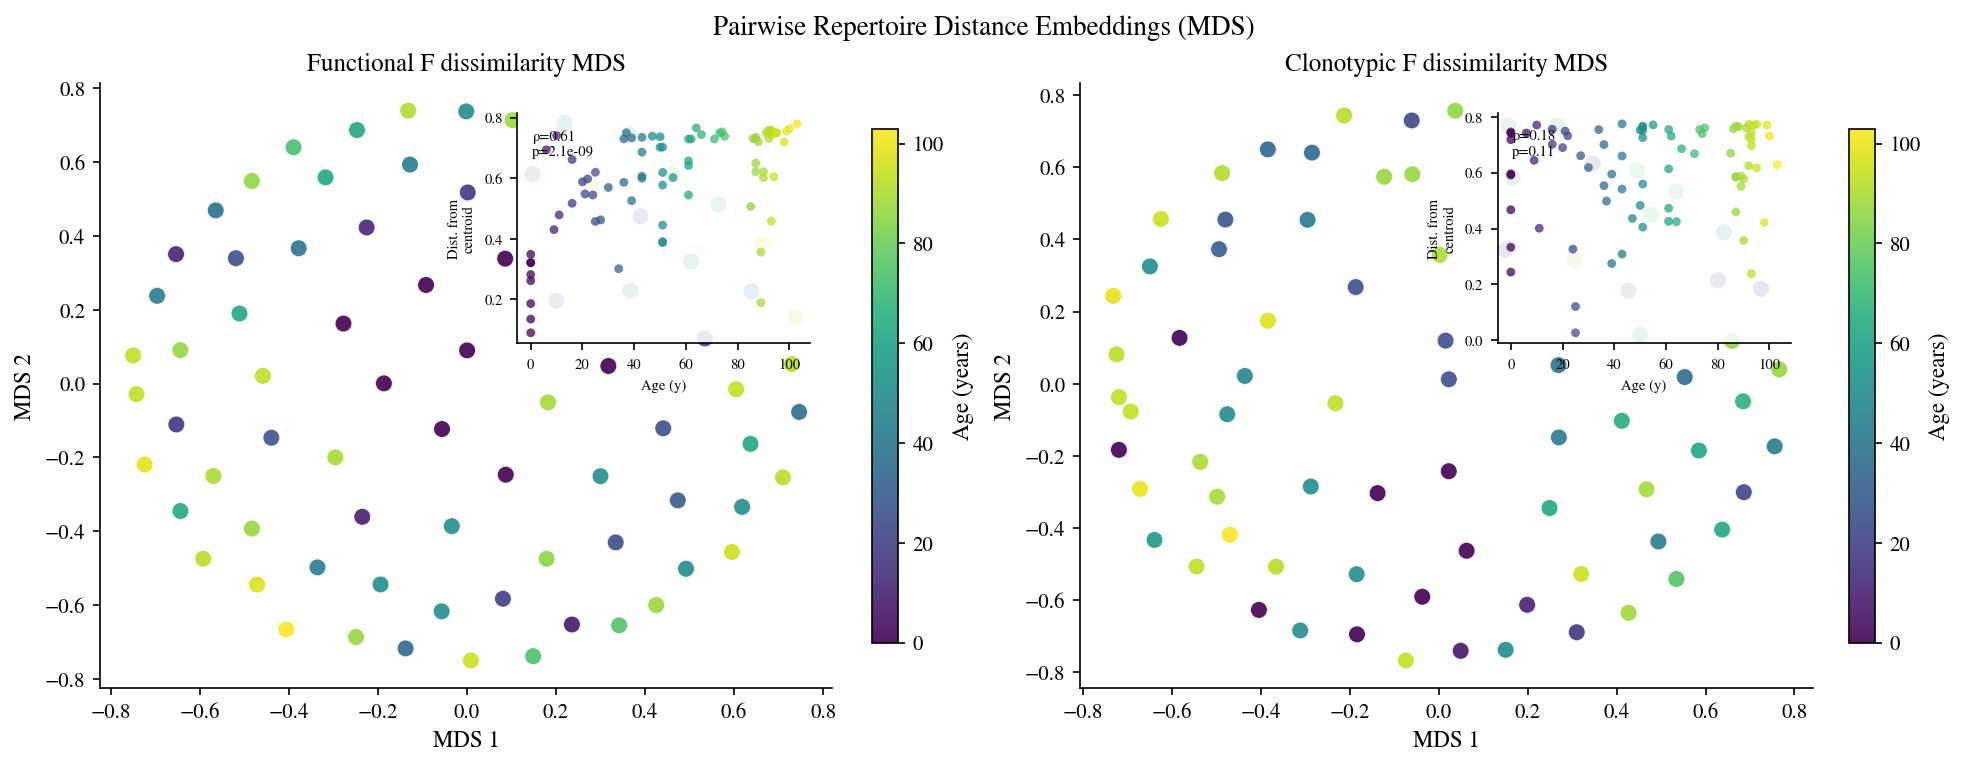

In [16]:
# Cell 16: MDS embedding of pairwise functional and clonotypic dissimilarities
# Distances are defined as dissimilarity = 1 − F_similarity (functional) or
# 1 − f_similarity (clonotypic).  MDS preserves pairwise distance structure.
from sklearn.manifold import MDS

def _pairs_to_dist_matrix(pairs_df, f_col: str, ids: list) -> np.ndarray:
    n = len(ids)
    idx = {sid: i for i, sid in enumerate(ids)}
    mat = np.zeros((n, n))
    for row in pairs_df.iter_rows(named=True):
        i = idx.get(row['sample_id_1'])
        j = idx.get(row['sample_id_2'])
        if i is None or j is None:
            continue
        v = row[f_col]
        d = 1.0 - (float(v) if v is not None else 0.0)
        mat[i, j] = d
        mat[j, i] = d
    return mat

func_dist  = _pairs_to_dist_matrix(func_pair_df, 'f_func', sample_ids)
clono_dist = _pairs_to_dist_matrix(clono_pairs, 'f_similarity', sample_ids)

_mds_kw = dict(
    n_components=2, dissimilarity='precomputed',
    normalized_stress='auto', random_state=42, n_init=4, max_iter=400,
)
mds_func  = MDS(**_mds_kw).fit_transform(func_dist)
mds_clono = MDS(**_mds_kw).fit_transform(clono_dist)

age_arr = np.array(ages, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, emb, title in zip(
    axes,
    [mds_func, mds_clono],
    ['Functional F dissimilarity MDS', 'Clonotypic F dissimilarity MDS'],
):
    sc = ax.scatter(
        emb[:, 0], emb[:, 1],
        c=age_arr, cmap='viridis', s=64, alpha=0.9,
        linewidths=0.3, edgecolors='white',
    )
    plt.colorbar(sc, ax=ax, label='Age (years)', shrink=0.85)
    ax.set_xlabel('MDS 1', fontsize=11)
    ax.set_ylabel('MDS 2', fontsize=11)
    ax.set_title(title, fontsize=12)

    # Inset: distance from MDS centroid vs age (Spearman ρ)
    centroid = emb.mean(axis=0)
    dist_from_c = np.linalg.norm(emb - centroid, axis=1)
    rho, pval = stats.spearmanr(age_arr, dist_from_c)
    axins = ax.inset_axes([0.57, 0.57, 0.40, 0.38])
    axins.scatter(age_arr, dist_from_c, c=age_arr, cmap='viridis',
                  s=18, alpha=0.75, edgecolors='none')
    axins.set_xlabel('Age (y)', fontsize=7)
    axins.set_ylabel('Dist. from\ncentroid', fontsize=7)
    axins.tick_params(labelsize=7)
    axins.text(0.05, 0.93, f'ρ={rho:.2f}\np={pval:.2g}',
               transform=axins.transAxes, fontsize=7, va='top')
    axins.set_facecolor('white')
    axins.patch.set_alpha(0.88)

fig.suptitle('Pairwise Repertoire Distance Embeddings (MDS)', fontsize=13)
plt.show()


## 8 · Functional donor-vs-pool F overlap

Build metaclonotype clusters for the pooled repertoire; then for each donor compute
the fraction of donor metaclonotypes that share identity with a pool metaclonotype.

In [17]:
# Cell 17: Cluster the pooled repertoire
# The raw pool has duplicates (same CDR3+V+J from multiple donors).
# Deduplicate by (junction_aa, v_call, j_call) before graph building.

from mir.common.sampling import downsample as _downsample

_key = lambda c: (c.junction_aa, c.v_call or '', c.j_call or '')
_seen: dict = {}
for c in pool_rep.clonotypes:
    k = _key(c)
    if k not in _seen:
        _seen[k] = c

pool_dedup_clonotypes = list(_seen.values())
MAX_POOL_GRAPH = 300_000
if len(pool_dedup_clonotypes) > MAX_POOL_GRAPH:
    import random as _rng
    _rng.seed(42)
    pool_dedup_clonotypes = _rng.sample(pool_dedup_clonotypes, MAX_POOL_GRAPH)
    print(f'Pool: {pool_rep.clonotype_count:,} raw → {MAX_POOL_GRAPH:,} unique (sampled)')
else:
    print(f'Pool: {pool_rep.clonotype_count:,} raw → {len(pool_dedup_clonotypes):,} unique clonotypes')

pool_rep_dedup = LocusRepertoire(clonotypes=pool_dedup_clonotypes, locus='TRB')

t0 = time.perf_counter()
pool_graph = build_edit_distance_graph(
    pool_rep_dedup.clonotypes,
    metric='hamming',
    threshold=METACLONOTYPE_THRESHOLD,
    n_jobs=N_JOBS,
)
meta_pool = metaclonotypes_from_graph_communities(
    pool_graph,
    method=METACLONOTYPE_METHOD,
    min_cluster_size=METACLONOTYPE_MIN_SIZE,
)
EXECUTION_TIMES['pool_cluster_s'] = time.perf_counter() - t0
print(f'Pool metaclonotypes: {meta_pool.n_clusters:,} in {EXECUTION_TIMES["pool_cluster_s"]:.1f}s')

Pool: 4,145,989 raw → 300,000 unique (sampled)


Skipping 9717 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 9717 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 9717 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 9717 sequences with non-canonical amino acids (*, _, or non-standard chars)


Pool metaclonotypes: 10,679 in 312.9s


Functional vs-pool: 79 samples in 22.9s


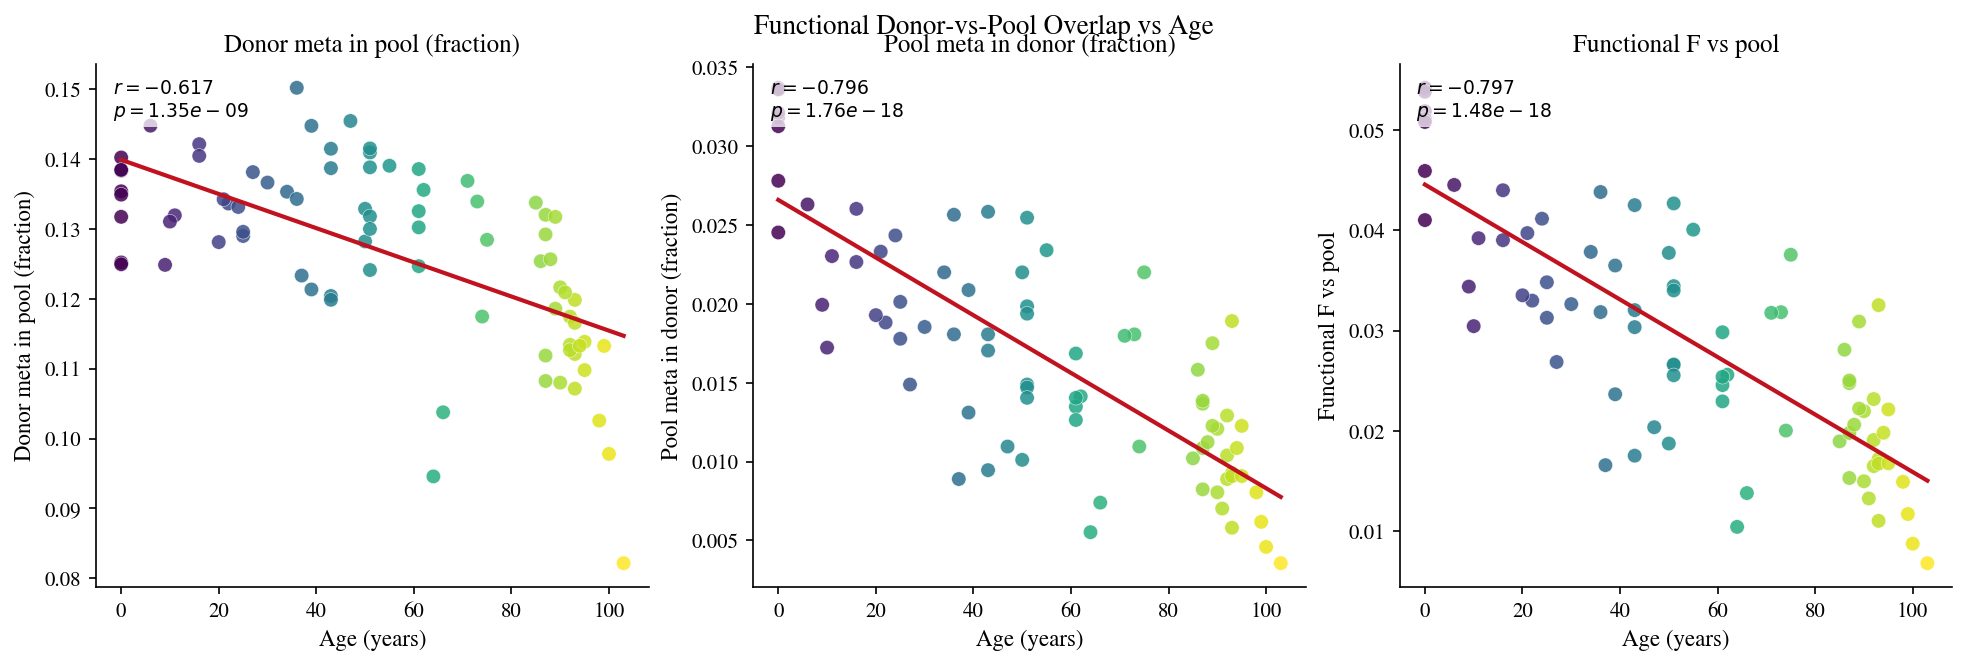

In [18]:
# Cell 18: Functional donor-vs-pool overlap
func_pool_rows = []
t0 = time.perf_counter()
for sid, age, rep, mc in zip(sample_ids, ages, reps, meta_clusterings):
    if mc.n_clusters == 0:
        continue
    r = functional_overlap_1(rep, mc, pool_rep_dedup, meta_pool)
    frac_donor = float(r['a_overlap_fraction'][0])  # fraction of donor meta shared with pool
    frac_pool  = float(r['b_overlap_fraction'][0])  # fraction of pool meta shared with donor
    denom = frac_donor + frac_pool
    f_func = 2 * frac_donor * frac_pool / denom if denom > 0 else 0.0
    func_pool_rows.append({
        'sample_id': sid, 'age': age,
        'frac_donor_in_pool': frac_donor,
        'frac_pool_in_donor': frac_pool,
        'f_func_pool': f_func,
    })
EXECUTION_TIMES['func_pool_s'] = time.perf_counter() - t0
func_pool_df = pl.DataFrame(func_pool_rows)
print(f'Functional vs-pool: {len(func_pool_rows)} samples in {EXECUTION_TIMES["func_pool_s"]:.1f}s')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for ax, (col, label) in zip(axes, [
    ('frac_donor_in_pool', 'Donor meta in pool (fraction)'),
    ('frac_pool_in_donor', 'Pool meta in donor (fraction)'),
    ('f_func_pool', 'Functional F vs pool'),
]):
    x = func_pool_df['age'].to_numpy().astype(float)
    y = func_pool_df[col].to_numpy().astype(float)
    ax.scatter(x, y, c=x, cmap='viridis', s=48, alpha=0.85, edgecolors='white', linewidths=0.25)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.text(0.03, 0.97, f'$r={r:.3f}$\n$p={p:.2e}$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
fig.suptitle('Functional Donor-vs-Pool Overlap vs Age', fontsize=13, y=1.02)
plt.show()

## 9 · Side-by-side: clonotypic vs functional metrics

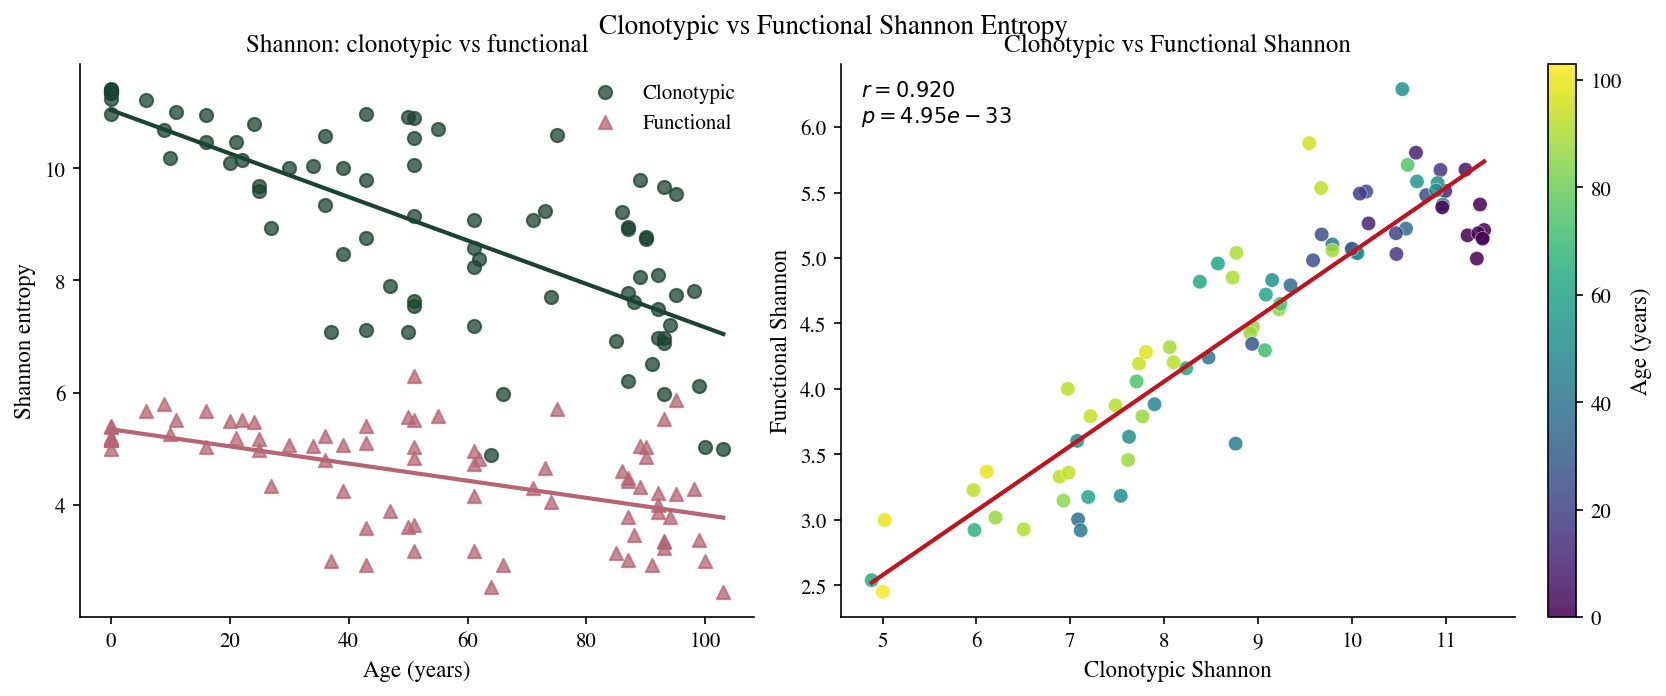

In [19]:
# Cell 19: Clonotypic vs functional Shannon entropy vs age
merged = clono_div_df.join(
    func_div_df.select(['sample_id', 'func_shannon']),
    on='sample_id', how='inner',
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

ax = axes[0]
x = merged['age'].to_numpy().astype(float)
yc = merged['shannon'].to_numpy().astype(float)
yf = merged['func_shannon'].to_numpy().astype(float)
ax.scatter(x, yc, s=40, alpha=0.75, color='#1B4332', label='Clonotypic')
ax.scatter(x, yf, s=40, alpha=0.75, color='#B56576', marker='^', label='Functional')
for col, color in [('shannon', '#1B4332'), ('func_shannon', '#B56576')]:
    y = merged[col].to_numpy().astype(float)
    slope, intercept, _, _, _ = stats.linregress(x, y)
    ax.plot(np.linspace(x.min(), x.max(), 200),
            slope * np.linspace(x.min(), x.max(), 200) + intercept,
            color=color, lw=2)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Shannon entropy')
ax.set_title('Shannon: clonotypic vs functional')
ax.legend(frameon=False)

# Correlation between clonotypic and functional Shannon
ax2 = axes[1]
ax2.scatter(yc, yf, c=x, cmap='viridis', s=48, alpha=0.85, edgecolors='white', linewidths=0.25)
slope2, intercept2, r2, p2, _ = stats.linregress(yc, yf)
xr2 = np.linspace(yc.min(), yc.max(), 200)
ax2.plot(xr2, slope2 * xr2 + intercept2, color='#C1121F', lw=2)
ax2.set_xlabel('Clonotypic Shannon')
ax2.set_ylabel('Functional Shannon')
ax2.set_title('Clonotypic vs Functional Shannon')
ax2.text(0.03, 0.97, f'$r={r2:.3f}$\n$p={p2:.2e}$',
         transform=ax2.transAxes, va='top', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
plt.colorbar(ax2.collections[0], ax=ax2, label='Age (years)')
fig.suptitle('Clonotypic vs Functional Shannon Entropy', fontsize=13, y=1.02)
plt.show()

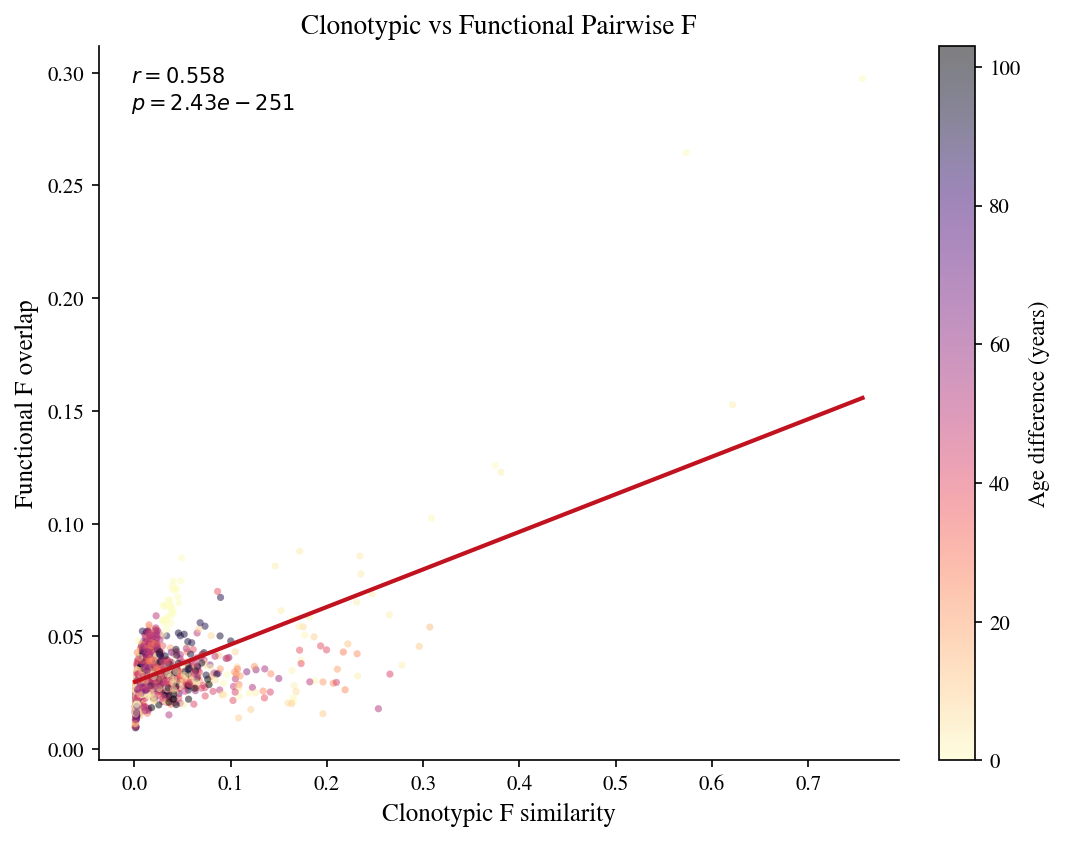

In [20]:
# Cell 20: Clonotypic vs functional pairwise F — correlation scatter
# 'combined' retains age_diff for the Spearman summary cell that follows.

clono_f = (
    clono_pairs
    .with_columns(pl.col('f_similarity').alias('f_clono'))
    .select(['sample_id_1', 'sample_id_2', 'f_clono'])
)

combined = clono_f.join(
    func_pair_df.select(['sample_id_1', 'sample_id_2', 'age_diff', 'f_func']),
    on=['sample_id_1', 'sample_id_2'],
    how='inner',
)

fc = combined['f_clono'].to_numpy().astype(float)
ff = combined['f_func'].to_numpy().astype(float)
age_diff = combined['age_diff'].to_numpy().astype(float)

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
sc = ax.scatter(fc, ff, c=age_diff, cmap='magma_r', s=12, alpha=0.5, edgecolors='none')
slope, intercept, r, p, _ = stats.linregress(fc, ff)
xr = np.linspace(fc.min(), fc.max(), 200)
ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2)
ax.set_xlabel('Clonotypic F similarity', fontsize=12)
ax.set_ylabel('Functional F overlap', fontsize=12)
ax.set_title('Clonotypic vs Functional Pairwise F', fontsize=13)
ax.text(0.04, 0.97, f'$r={r:.3f}$\n$p={p:.2e}$',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
plt.colorbar(sc, ax=ax, label='Age difference (years)')
plt.show()


## 10 · Age correlation summary

In [21]:
# Cell 21: Spearman correlations with age — all metrics
import polars as pl

summary_rows = []

# Per-sample metrics
combined_per_sample = (
    clono_div_df
    .join(func_div_df.select(['sample_id', 'func_shannon', 'func_gini_simpson', 'func_chao1']),
          on='sample_id', how='inner')
    .join(cluster_df.select(['sample_id', 'n_clusters', 'compression']),
          on='sample_id', how='left')
    .join(func_pool_df.select(['sample_id', 'frac_donor_in_pool', 'f_func_pool']),
          on='sample_id', how='left')
)
age_vec = combined_per_sample['age'].to_numpy().astype(float)

for col, label in [
    ('n_clonotypes',       'Clonotypic richness (observed)'),
    ('shannon',            'Clonotypic Shannon'),
    ('gini_simpson',       'Clonotypic Gini-Simpson'),
    ('chao1',              'Clonotypic Chao1'),
    ('n_clusters',         'Metaclonotype count'),
    ('compression',        'Compression (meta/clono)'),
    ('func_shannon',       'Functional Shannon'),
    ('func_gini_simpson',  'Functional Gini-Simpson'),
    ('func_chao1',         'Functional Chao1'),
    ('frac_donor_in_pool', 'Func fraction in pool'),
    ('f_func_pool',        'Functional F vs pool'),
]:
    if col not in combined_per_sample.columns:
        continue
    vals = combined_per_sample[col].to_numpy().astype(float)
    mask = np.isfinite(age_vec) & np.isfinite(vals)
    if mask.sum() < 3:
        continue
    rho, pval = stats.spearmanr(age_vec[mask], vals[mask])
    summary_rows.append({'metric': label, 'level': 'sample', 'rho': round(rho, 3), 'p_value': round(pval, 4)})

# Pairwise metrics vs age difference
for df, col, label in [
    (combined, 'f_clono', 'Clonotypic pairwise F'),
    (combined, 'f_func',  'Functional pairwise F'),
]:
    if col not in df.columns:
        continue
    x = df['age_diff'].to_numpy().astype(float)
    y = df[col].to_numpy().astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        continue
    rho, pval = stats.spearmanr(x[mask], y[mask])
    summary_rows.append({'metric': label + ' ~ age_diff', 'level': 'pair', 'rho': round(rho, 3), 'p_value': round(pval, 4)})

summary_table = pl.DataFrame(summary_rows).sort('rho')
print('Spearman ρ with age (sample metrics) or age_diff (pairwise metrics):')
print(summary_table.to_pandas().to_string(index=False))

print('\nExecution timing:')
for k, v in EXECUTION_TIMES.items():
    print(f'  {k:<30} {v:.1f}s')

Spearman ρ with age (sample metrics) or age_diff (pairwise metrics):
                          metric  level    rho  p_value
            Functional F vs pool sample -0.790   0.0000
              Clonotypic Shannon sample -0.746   0.0000
             Metaclonotype count sample -0.720   0.0000
                Functional Chao1 sample -0.720   0.0000
         Clonotypic Gini-Simpson sample -0.685   0.0000
                Clonotypic Chao1 sample -0.681   0.0000
           Func fraction in pool sample -0.640   0.0000
         Functional Gini-Simpson sample -0.555   0.0000
              Functional Shannon sample -0.537   0.0000
  Clonotypic richness (observed) sample -0.127   0.2663
Functional pairwise F ~ age_diff   pair -0.081   0.0000
Clonotypic pairwise F ~ age_diff   pair -0.009   0.6310
        Compression (meta/clono) sample  0.795   0.0000

Execution timing:
  asset_refresh_s                0.6s
  load_s                         108.4s
  clono_pairwise_s               25.8s
  clono_poo